In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from wordcloud import WordCloud
import squarify
import ipytest
import pytest
import warnings
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
warnings.filterwarnings('ignore')
from core.data import load_from_kaggle


In [14]:
dataset_link = "milanzdravkovic/pharma-sales-data" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    );

Destination directory '../data/raw\pharma-sales-data' already exists with files. Skipping download (replace=False).


In [15]:
files

['salesdaily.csv', 'saleshourly.csv', 'salesmonthly.csv', 'salesweekly.csv']

In [16]:
for file in files:
    file_name = file
    df_file = pd.read_csv("/".join(["../data/raw/", dataset_name, file]))
    print(file_name)
    display(df_file)
    display(
    "Shape",
    df_file.shape,
    "Description",
    df_file.describe().round(2).T,
    "Duplicates",
    df_file.duplicated().sum(),
)
    print("Fehlende Werte")
    display(df_file.isna().sum())
    display(pd.DataFrame(
    {
        "Data Types": df_file.dtypes,
        "Missing Values": df_file.isnull().sum(),
        "Unique Values": df_file.nunique(),
        "Sample Values": [df_file[col].sample(3).tolist() for col in df_file.columns]
    }))
    print('\n'*2)

salesdaily.csv


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.00,3.670,3.40,32.40,7.0,0.0,0.0,2.00,2014,1,248,Thursday
1,1/3/2014,8.00,4.000,4.40,50.60,16.0,0.0,20.0,4.00,2014,1,276,Friday
2,1/4/2014,2.00,1.000,6.50,61.85,10.0,0.0,9.0,1.00,2014,1,276,Saturday
3,1/5/2014,4.00,3.000,7.00,41.10,8.0,0.0,3.0,0.00,2014,1,276,Sunday
4,1/6/2014,5.00,1.000,4.50,21.70,16.0,2.0,6.0,2.00,2014,1,276,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,10/4/2019,7.34,5.683,2.25,22.45,13.0,0.0,1.0,1.00,2019,10,276,Friday
2102,10/5/2019,3.84,5.010,6.00,25.40,7.0,0.0,0.0,0.33,2019,10,276,Saturday
2103,10/6/2019,4.00,11.690,2.00,34.60,6.0,0.0,5.0,4.20,2019,10,276,Sunday
2104,10/7/2019,7.34,4.507,3.00,50.80,6.0,0.0,10.0,1.00,2019,10,276,Monday


'Shape'

(2106, 13)

'Description'

...

'Duplicates'

np.int64(0)

Fehlende Werte


datum    0
M01AB    0
M01AE    0
N02BA    0
N02BE    0
N05B     0
N05C     0
R03      0
R06      0
dtype: int64

,Data Types,Missing Values,Unique Values,Sample Values
datum,object,0,302,"[8/9/2015, 1/31/2016, 1/15/2017]"
M01AB,float64,0,260,"[48.74583333, 32.35, 32.66]"
M01AE,float64,0,300,"[17.4, 14.703, 31.263]"
N02BA,float64,0,222,"[25.05, 23.5, 20.0]"
N02BE,float64,0,293,"[298.8, 244.662, 342.2]"
N05B,float64,0,115,"[38.0, 98.0, 68.0]"
N05C,float64,0,24,"[1.0, 3.0, 8.0]"
R03,float64,0,97,"[36.0, 35.0, 21.0]"
R06,float64,0,169,"[23.0, 15.83333333, 28.0]"


In [17]:
df_salesdaily = pd.read_csv("../data/raw/pharma-sales-data/salesdaily.csv")
df_saleshourly = pd.read_csv("../data/raw/pharma-sales-data/saleshourly.csv")
df_salesweekly = pd.read_csv("../data/raw/pharma-sales-data/salesweekly.csv")
df_salesmonthly = pd.read_csv("../data/raw/pharma-sales-data/salesmonthly.csv")

In [18]:
for file in files:
    df_file['datum'] = pd.to_datetime(df_file['datum'])
    print('file name', file)
    print(df_file.dtypes)
    print('\n')

file name salesdaily.csv
datum    datetime64[ns]
M01AB           float64
M01AE           float64
N02BA           float64
N02BE           float64
N05B            float64
N05C            float64
R03             float64
R06             float64
dtype: object


file name saleshourly.csv
datum    datetime64[ns]
M01AB           float64
M01AE           float64
N02BA           float64
N02BE           float64
N05B            float64
N05C            float64
R03             float64
R06             float64
dtype: object


file name salesmonthly.csv
datum    datetime64[ns]
M01AB           float64
M01AE           float64
N02BA           float64
N02BE           float64
N05B            float64
N05C            float64
R03             float64
R06             float64
dtype: object


file name salesweekly.csv
datum    datetime64[ns]
M01AB           float64
M01AE           float64
N02BA           float64
N02BE           float64
N05B            float64
N05C            float64
R03             float64
R06     

In [22]:
dfs = {
    "salesdaily": df_salesdaily,
    "saleshourly": df_saleshourly,
    "salesmonthly": df_salesmonthly,
    "salesweekly": df_salesweekly
}


===== salesdaily =====
M01AB: 26 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
513,5/30/2015,14.00,2.680,6.0,24.5,4.0,0.0,4.0,8.0,2015,5,276,Saturday
572,7/28/2015,14.18,6.020,1.0,15.2,14.0,0.0,1.0,3.0,2015,7,276,Tuesday
586,8/11/2015,12.33,6.660,7.4,18.1,10.0,0.0,0.0,4.0,2015,8,276,Tuesday
632,9/26/2015,12.42,3.330,2.5,33.0,6.0,1.0,7.0,2.0,2015,9,276,Saturday
761,2/2/2016,14.33,4.878,1.3,39.0,6.0,0.0,0.0,1.0,2016,2,276,Tuesday


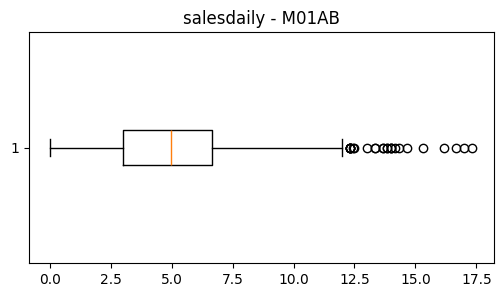

M01AE: 40 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
39,2/10/2014,5.00,10.33,8.5,40.1,20.0,3.0,3.0,1.0,2014,2,276,Monday
309,11/7/2014,6.00,10.34,5.5,15.8,32.0,1.0,0.0,1.0,2014,11,276,Friday
360,12/28/2014,2.34,10.76,3.0,80.4,15.0,0.0,13.0,1.0,2014,12,276,Sunday
369,1/6/2015,3.00,9.37,7.3,42.0,13.0,0.0,3.0,0.0,2015,1,276,Tuesday
604,8/29/2015,10.84,10.34,4.0,23.2,4.0,3.0,3.0,2.0,2015,8,276,Saturday


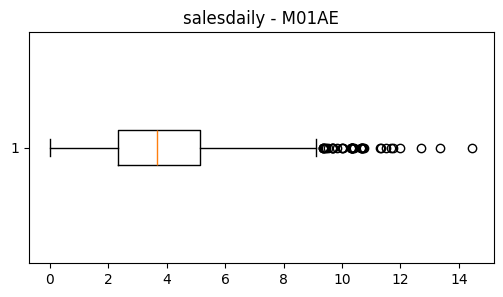

N02BA: 31 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
6,1/8/2014,5.33,3.00,10.5,26.4,19.0,1.0,10.0,0.0,2014,1,276,Wednesday
9,1/11/2014,5.00,4.34,10.4,52.3,14.0,0.0,1.0,0.2,2014,1,276,Saturday
12,1/14/2014,6.00,1.33,12.3,33.7,6.0,1.0,0.0,2.0,2014,1,276,Tuesday
36,2/7/2014,2.66,8.67,11.7,21.4,19.0,1.0,0.0,0.0,2014,2,276,Friday
37,2/8/2014,3.33,3.35,14.4,37.1,13.0,1.0,1.0,1.0,2014,2,276,Saturday


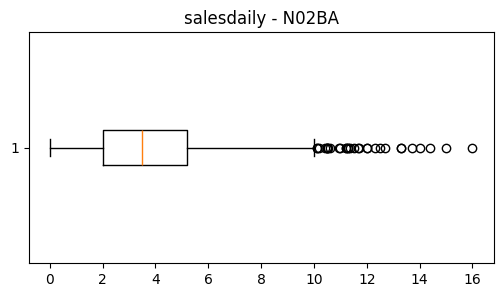

N02BE: 48 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
41,2/12/2014,9.00,1.670,9.1,73.600,9.0,0.0,5.0,0.0,2014,2,276,Wednesday
277,10/6/2014,5.34,1.365,2.4,69.875,13.0,1.0,0.0,1.0,2014,10,276,Monday
360,12/28/2014,2.34,10.760,3.0,80.400,15.0,0.0,13.0,1.0,2014,12,276,Sunday
641,10/5/2015,5.00,2.373,2.2,70.950,11.0,1.0,7.0,5.0,2015,10,276,Monday
647,10/11/2015,10.33,2.792,7.1,70.300,8.0,0.0,3.0,5.0,2015,10,276,Sunday


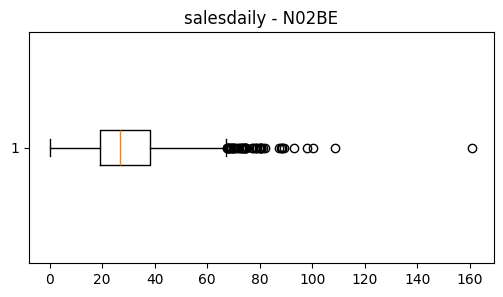

N05B: 48 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
173,6/24/2014,3.00,5.14,4.0,16.2,23.0,0.0,2.0,4.0,2014,6,276,Tuesday
189,7/10/2014,2.33,4.66,8.0,21.2,32.0,0.0,5.0,4.0,2014,7,276,Thursday
219,8/9/2014,4.00,1.34,6.0,19.0,24.0,3.0,0.0,5.9,2014,8,276,Saturday
226,8/16/2014,8.00,2.43,5.0,19.0,27.0,2.0,0.0,1.0,2014,8,276,Saturday
247,9/6/2014,5.34,5.00,2.4,15.7,30.0,2.0,5.0,3.1,2014,9,276,Saturday


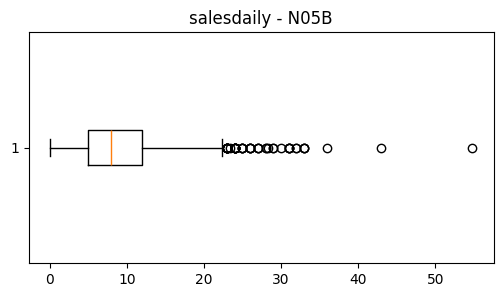

N05C: 160 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
16,1/18/2014,1.00,5.33,5.8,43.20,15.0,4.0,7.0,2.0,2014,1,276,Saturday
21,1/23/2014,4.00,4.67,5.2,26.20,2.0,3.0,1.0,3.0,2014,1,276,Thursday
26,1/28/2014,6.00,3.34,2.8,13.38,22.0,5.0,1.0,5.0,2014,1,276,Tuesday
39,2/10/2014,5.00,10.33,8.5,40.10,20.0,3.0,3.0,1.0,2014,2,276,Monday
42,2/13/2014,4.33,3.67,10.0,49.10,13.0,3.0,0.0,1.0,2014,2,276,Thursday


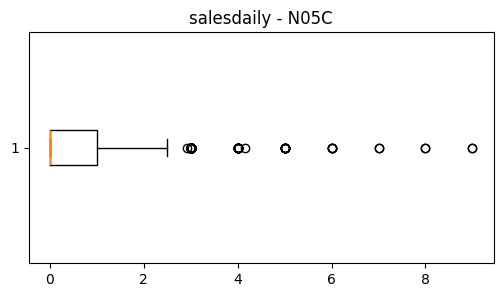

R03: 124 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
1,1/3/2014,8.00,4.00,4.4,50.6,16.0,0.0,20.0,4.0,2014,1,276,Friday
70,3/13/2014,2.31,4.36,5.3,15.5,10.0,0.0,26.0,2.0,2014,3,276,Thursday
131,5/13/2014,3.68,0.34,6.2,32.0,7.0,0.0,25.0,7.5,2014,5,276,Tuesday
258,9/17/2014,2.34,6.00,4.0,39.6,11.0,2.0,19.0,4.0,2014,9,276,Wednesday
260,9/19/2014,2.00,4.34,7.8,23.0,8.0,0.0,22.0,0.0,2014,9,276,Friday


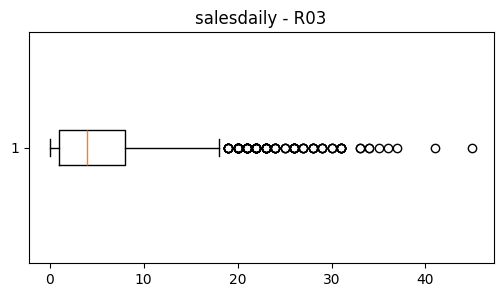

R06: 81 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
125,5/7/2014,3.33,6.320,3.0,16.8,8.0,1.0,3.0,11.0,2014,5,276,Wednesday
137,5/19/2014,8.34,3.840,6.1,12.8,5.0,0.0,3.0,9.0,2014,5,276,Monday
142,5/24/2014,3.00,4.713,5.0,28.0,11.0,1.0,0.0,9.0,2014,5,276,Saturday
158,6/9/2014,6.33,1.340,5.0,18.0,17.0,4.0,0.0,11.0,2014,6,276,Monday
160,6/11/2014,4.34,0.680,2.3,12.5,16.0,2.0,12.0,9.0,2014,6,276,Wednesday


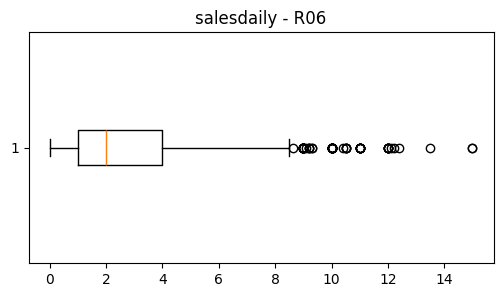

Year: 0 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name


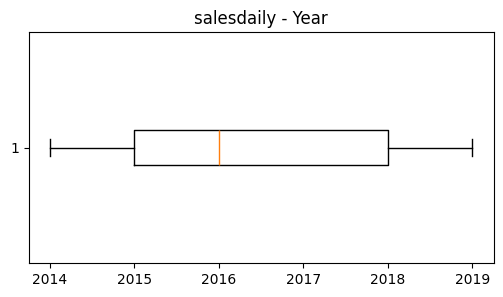

Month: 0 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name


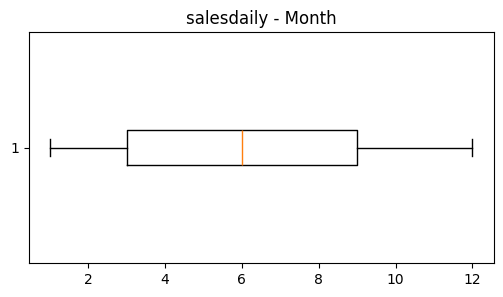

Hour: 2 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.00,3.67,3.4,32.4,7.0,0.0,0.0,2.0,2014,1,248,Thursday
2105,10/8/2019,0.33,1.73,0.5,44.3,20.0,2.0,2.0,0.0,2019,10,190,Tuesday


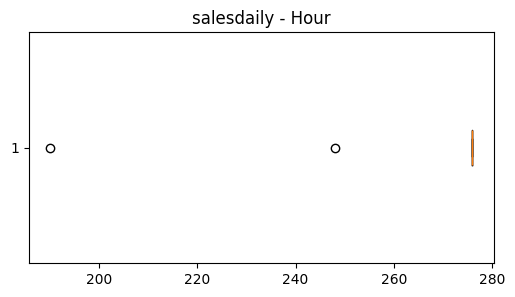


===== saleshourly =====
M01AB: 8899 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
26,1/3/2014 10:00,1.0,2.0,0.0,4.1,2.0,0.0,0.0,0.0,2014,1,10,Friday
27,1/3/2014 11:00,4.0,0.0,1.0,8.0,4.0,0.0,0.0,0.0,2014,1,11,Friday
29,1/3/2014 13:00,1.0,1.0,0.0,3.0,2.0,0.0,0.0,0.0,2014,1,13,Friday
31,1/3/2014 15:00,1.0,0.0,0.0,3.0,0.0,0.0,6.0,2.0,2014,1,15,Friday
33,1/3/2014 17:00,1.0,0.0,1.0,4.0,1.0,0.0,0.0,1.0,2014,1,17,Friday


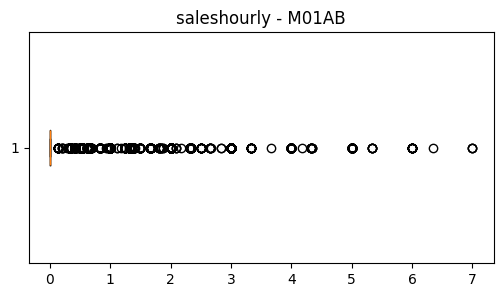

M01AE: 9515 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014 8:00,0.0,0.67,0.4,2.0,0.0,0.0,0.0,1.0,2014,1,8,Thursday
4,1/2/2014 12:00,0.0,2.00,0.0,5.0,2.0,0.0,0.0,0.0,2014,1,12,Thursday
5,1/2/2014 13:00,0.0,1.00,2.0,20.4,0.0,0.0,0.0,1.0,2014,1,13,Thursday
26,1/3/2014 10:00,1.0,2.00,0.0,4.1,2.0,0.0,0.0,0.0,2014,1,10,Friday
29,1/3/2014 13:00,1.0,1.00,0.0,3.0,2.0,0.0,0.0,0.0,2014,1,13,Friday


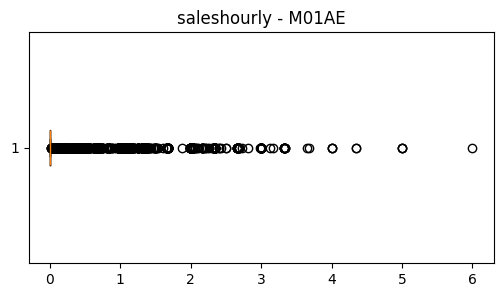

N02BA: 7446 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014 8:00,0.0,0.67,0.4,2.0,0.0,0.0,0.0,1.0,2014,1,8,Thursday
1,1/2/2014 9:00,0.0,0.00,1.0,0.0,2.0,0.0,0.0,0.0,2014,1,9,Thursday
5,1/2/2014 13:00,0.0,1.00,2.0,20.4,0.0,0.0,0.0,1.0,2014,1,13,Thursday
25,1/3/2014 9:00,0.0,0.00,1.0,1.0,0.0,0.0,0.0,0.0,2014,1,9,Friday
27,1/3/2014 11:00,4.0,0.00,1.0,8.0,4.0,0.0,0.0,0.0,2014,1,11,Friday


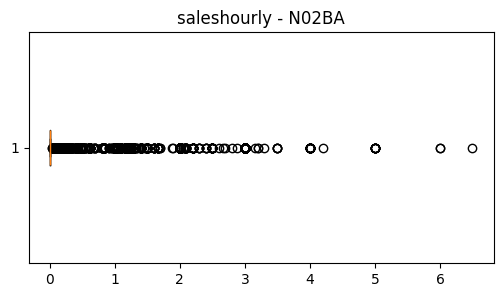

N02BE: 4189 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
4,1/2/2014 12:00,0.0,2.0,0.0,5.0,2.0,0.0,0.0,0.0,2014,1,12,Thursday
5,1/2/2014 13:00,0.0,1.0,2.0,20.4,0.0,0.0,0.0,1.0,2014,1,13,Thursday
27,1/3/2014 11:00,4.0,0.0,1.0,8.0,4.0,0.0,0.0,0.0,2014,1,11,Friday
28,1/3/2014 12:00,0.0,0.0,0.4,10.4,4.0,0.0,10.0,1.0,2014,1,12,Friday
36,1/3/2014 20:00,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,2014,1,20,Friday


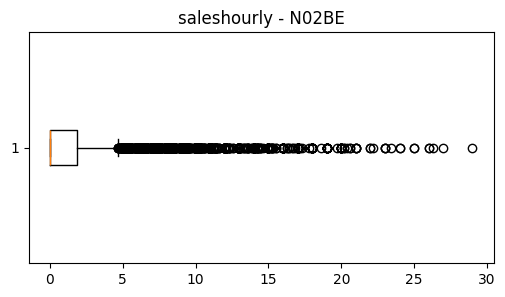

N05B: 10558 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
1,1/2/2014 9:00,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,2014,1,9,Thursday
2,1/2/2014 10:00,0.0,0.0,0.0,3.0,2.0,0.0,0.0,0.0,2014,1,10,Thursday
3,1/2/2014 11:00,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,2014,1,11,Thursday
4,1/2/2014 12:00,0.0,2.0,0.0,5.0,2.0,0.0,0.0,0.0,2014,1,12,Thursday
23,1/3/2014 7:00,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2014,1,7,Friday


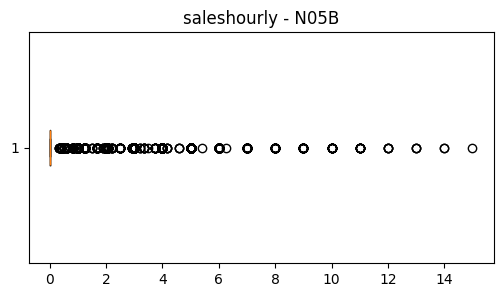

N05C: 864 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
101,1/6/2014 13:00,1.0,0.0,0.0,8.0,1.0,2.0,0.0,1.0,2014,1,13,Monday
151,1/8/2014 15:00,1.0,0.0,0.0,2.4,1.0,1.0,0.0,0.0,2014,1,15,Wednesday
195,1/10/2014 11:00,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,2014,1,11,Friday
196,1/10/2014 12:00,0.0,0.0,0.0,10.3,1.0,1.0,0.0,0.0,2014,1,12,Friday
295,1/14/2014 15:00,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,2014,1,15,Tuesday


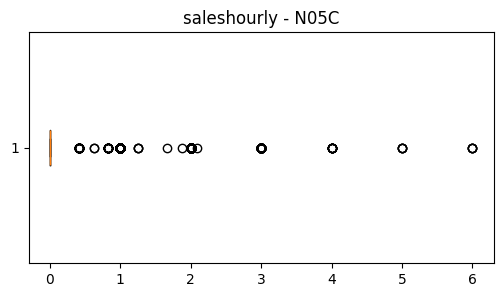

R03: 3412 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
28,1/3/2014 12:00,0.0,0.0,0.4,10.4,4.0,0.0,10.0,1.0,2014,1,12,Friday
30,1/3/2014 14:00,0.0,0.0,0.0,3.0,0.0,0.0,1.0,0.0,2014,1,14,Friday
31,1/3/2014 15:00,1.0,0.0,0.0,3.0,0.0,0.0,6.0,2.0,2014,1,15,Friday
32,1/3/2014 16:00,0.0,1.0,0.0,4.2,0.0,0.0,2.0,0.0,2014,1,16,Friday
35,1/3/2014 19:00,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2014,1,19,Friday


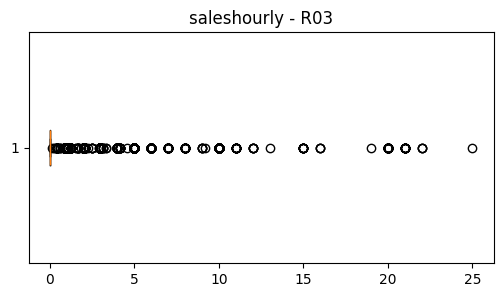

R06: 5285 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014 8:00,0.0,0.67,0.4,2.0,0.0,0.0,0.0,1.0,2014,1,8,Thursday
5,1/2/2014 13:00,0.0,1.00,2.0,20.4,0.0,0.0,0.0,1.0,2014,1,13,Thursday
28,1/3/2014 12:00,0.0,0.00,0.4,10.4,4.0,0.0,10.0,1.0,2014,1,12,Friday
31,1/3/2014 15:00,1.0,0.00,0.0,3.0,0.0,0.0,6.0,2.0,2014,1,15,Friday
33,1/3/2014 17:00,1.0,0.00,1.0,4.0,1.0,0.0,0.0,1.0,2014,1,17,Friday


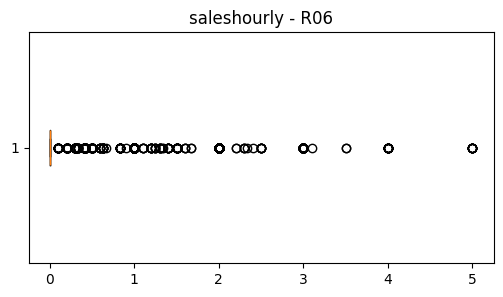

Year: 0 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name


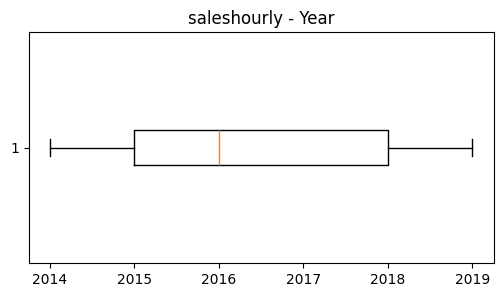

Month: 0 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name


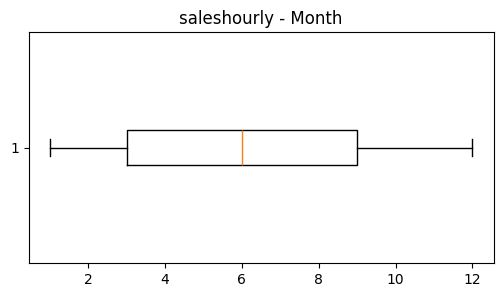

Hour: 0 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name


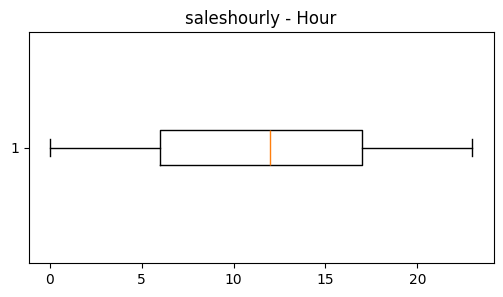


===== salesmonthly =====
M01AB: 2 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
36,2017-01-31,0.00,0.0,0.00,0.00,1.0,0.0,0.0,0.00
69,2019-10-31,44.37,37.3,20.65,295.15,86.0,7.0,37.0,11.13


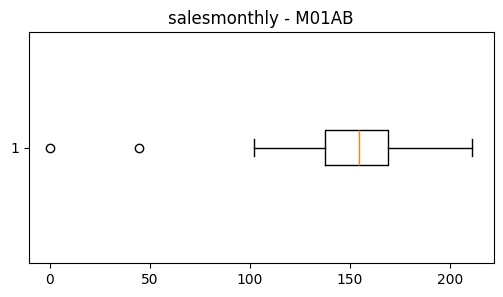

M01AE: 5 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
9,2014-10-31,154.75,185.241,191.60,1856.815,472.0,30.0,182.0,74.50
26,2016-03-31,156.64,180.589,148.40,1150.700,250.0,13.0,253.0,97.84
36,2017-01-31,0.00,0.000,0.00,0.000,1.0,0.0,0.0,0.00
60,2019-01-31,179.70,222.351,99.70,1660.612,295.2,23.0,386.0,41.30
69,2019-10-31,44.37,37.300,20.65,295.150,86.0,7.0,37.0,11.13


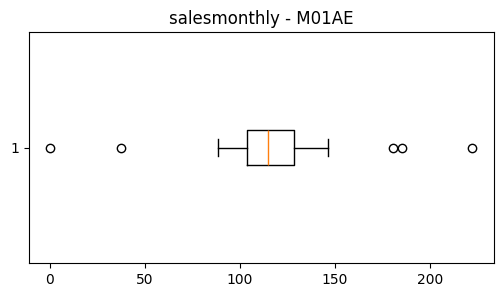

N02BA: 2 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
36,2017-01-31,0.00,0.0,0.00,0.00,1.0,0.0,0.0,0.00
69,2019-10-31,44.37,37.3,20.65,295.15,86.0,7.0,37.0,11.13


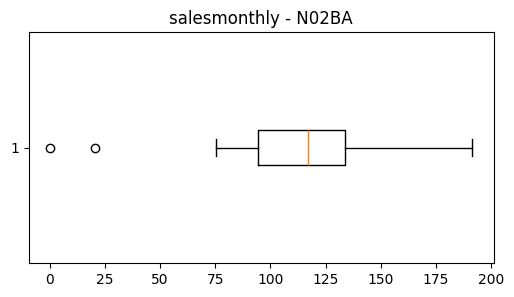

N02BE: 2 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
9,2014-10-31,154.75,185.241,191.6,1856.815,472.0,30.0,182.0,74.5
36,2017-01-31,0.00,0.000,0.0,0.000,1.0,0.0,0.0,0.0


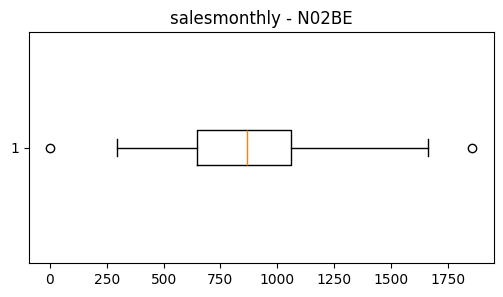

N05B: 8 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
7,2014-08-31,134.79,99.780,123.800,583.850,420.0,29.0,37.0,70.8
8,2014-09-30,108.78,109.094,122.100,887.820,399.0,14.0,115.0,58.8
9,2014-10-31,154.75,185.241,191.600,1856.815,472.0,30.0,182.0,74.5
10,2014-11-30,138.08,100.860,142.700,723.800,489.0,19.0,112.0,45.2
11,2014-12-31,131.90,121.401,111.124,1015.660,492.0,25.0,163.0,33.4


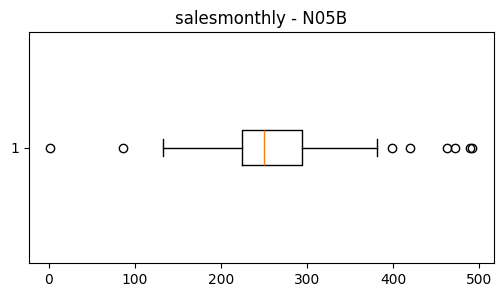

N05C: 2 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-31,127.69,99.090,152.1,878.030,354.0,50.0,112.0,48.2
50,2018-03-31,146.16,111.764,122.3,999.123,381.0,42.0,269.0,85.5


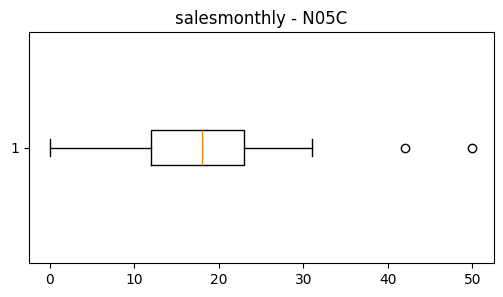

R03: 2 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
59,2018-12-31,147.71,113.024,84.75,1213.950,254.0,27.0,384.0,53.1
60,2019-01-31,179.70,222.351,99.70,1660.612,295.2,23.0,386.0,41.3


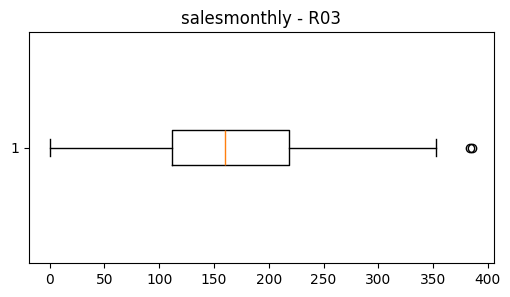

R06: 0 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06


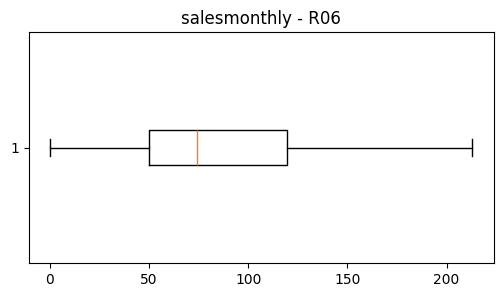


===== salesweekly =====
M01AB: 4 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
125,5/29/2016,59.68,19.906,34.60,228.350,78.0,10.0,21.0,40.4
143,10/2/2016,65.33,26.178,34.35,382.338,44.0,5.0,38.0,17.2
277,4/28/2019,57.70,14.514,21.95,181.300,67.0,6.0,62.0,36.4
301,10/13/2019,7.67,6.237,3.50,95.100,26.0,2.0,12.0,1.0


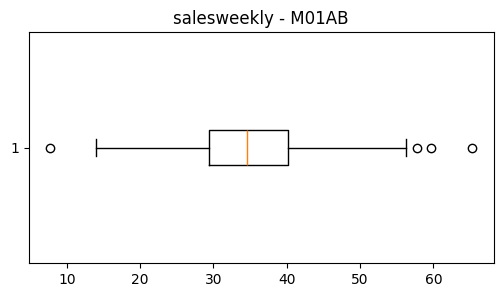

M01AE: 8 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
30,8/3/2014,20.02,7.710,23.20,95.100,80.0,9.0,11.0,16.50
114,3/13/2016,28.83,44.870,25.10,255.700,41.0,2.0,62.0,12.34
115,3/20/2016,42.64,48.752,32.90,244.662,67.0,3.0,81.0,26.00
263,1/20/2019,51.19,52.069,27.95,384.050,69.0,3.0,121.0,13.00
264,1/27/2019,38.35,53.243,22.50,478.300,69.0,9.0,93.0,9.00


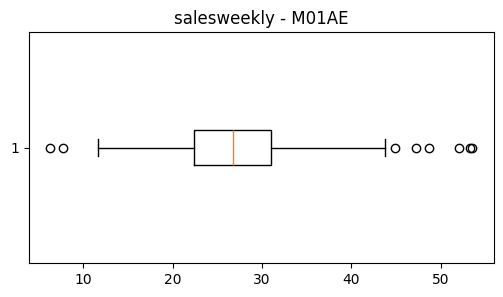

N02BA: 4 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
5,2/9/2014,22.650000,29.720000,53.300,226.800000,98.0,7.000000,31.000000,6.000000
106,1/17/2016,51.670000,27.211000,50.500,365.250000,82.0,0.000000,21.000000,12.000000
158,1/15/2017,48.745833,34.275417,60.125,368.479167,120.0,5.416667,31.666667,12.166667
301,10/13/2019,7.670000,6.237000,3.500,95.100000,26.0,2.000000,12.000000,1.000000


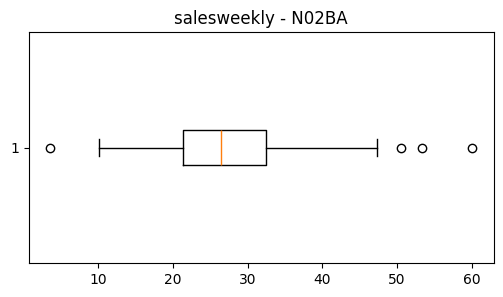

N02BE: 4 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
93,10/18/2015,42.66000,40.09300,35.900000,423.174,41.50,1.000,32.00,16.000
144,10/9/2016,36.35000,31.95700,35.500000,418.187,30.00,2.000,46.00,13.500
156,1/1/2017,49.20375,42.70525,31.529167,546.899,53.75,6.875,55.25,4.625
264,1/27/2019,38.35000,53.24300,22.500000,478.300,69.00,9.000,93.00,9.000


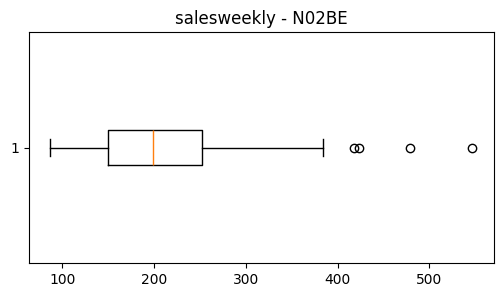

N05B: 17 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
34,8/31/2014,22.05,31.275,29.0,160.15,112.0,3.0,12.0,15.0
35,9/7/2014,29.70,29.369,23.6,113.72,109.0,5.0,9.0,18.6
43,11/2/2014,25.67,14.820,34.1,203.80,112.5,4.0,39.0,7.0
44,11/9/2014,40.67,31.050,29.8,177.90,152.0,5.0,25.0,6.2
45,11/16/2014,31.67,24.340,31.3,177.10,110.0,4.0,22.0,10.2


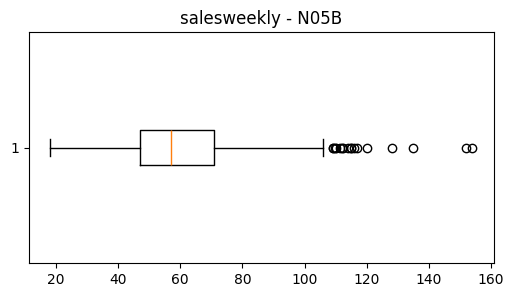

N05C: 6 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
6,2/16/2014,33.33,30.690,47.30,320.700,89.0,14.0,18.0,16.2
175,5/14/2017,38.98,23.892,31.95,109.900,36.0,14.0,24.0,40.7
195,10/1/2017,20.67,27.098,17.60,323.050,42.0,13.0,98.0,4.0
217,3/4/2018,19.33,20.772,33.20,256.549,115.0,16.0,68.0,14.5
218,3/11/2018,36.65,29.928,33.75,223.900,91.0,17.0,68.0,16.4


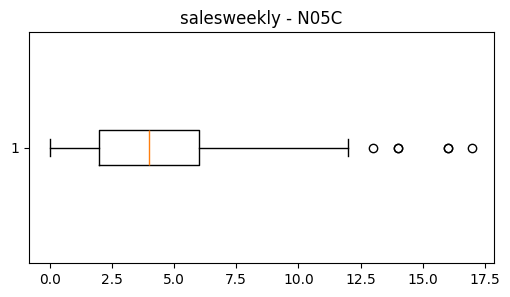

R03: 7 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
195,10/1/2017,20.67,27.098,17.60,323.050,42.0,13.0,98.0,4.0
251,10/28/2018,32.00,30.677,20.15,300.725,71.0,6.0,116.0,14.8
254,11/18/2018,37.34,26.113,28.00,236.100,63.0,5.0,100.0,7.4
258,12/16/2018,23.34,21.913,19.70,249.700,51.0,5.0,98.0,10.8
263,1/20/2019,51.19,52.069,27.95,384.050,69.0,3.0,121.0,13.0


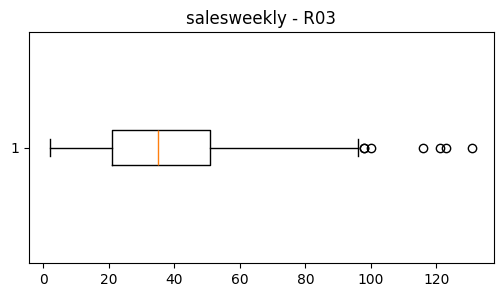

R06: 8 Ausreißer


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
223,4/15/2018,38.83,22.308,23.50,175.700,64.0,3.0,52.0,53.5
225,4/29/2018,50.67,25.443,25.05,155.912,60.0,3.0,66.0,56.4
226,5/6/2018,29.01,28.895,18.25,136.737,53.0,0.0,26.0,65.0
227,5/13/2018,53.82,24.282,25.15,160.800,66.0,4.0,31.0,51.0
272,3/24/2019,35.99,20.661,13.95,196.600,68.4,2.0,74.0,48.0


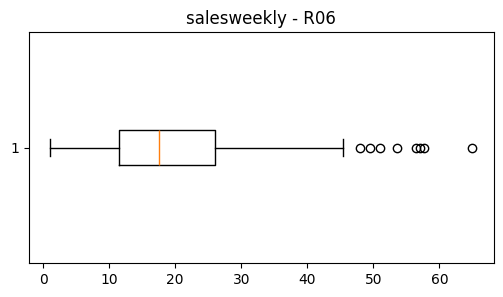

In [24]:
for name, df in dfs.items():

    print(f"\n===== {name} =====")

    numeric_cols = df.select_dtypes(include="number").columns

    for col in numeric_cols:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]

        print(f"{col}: {len(outliers)} Ausreißer")

        display(outliers.head())

        plt.figure(figsize=(6,3))
        plt.boxplot(df[col], vert=False)
        plt.title(f"{name} - {col}")
        plt.show()

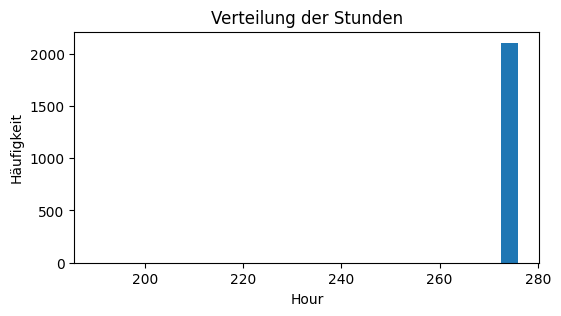